### Import the Allowed Tools & Load Data

In [11]:
# 1. Pandas & NumPy for Data Manipulation
import pandas as pd
import numpy as np

# 2. Matplotlib & Seaborn for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn for Preprocessing, Modeling, and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('Churn_Modelling.csv') # Ensure your file is named 'churn.csv'

### Exploratory Data Analysis (EDA)

In [12]:
# 1. Drop columns that are irrelevant to the prediction
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)



In [13]:
# Check basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB
None


C:\Users\erraj\AppData\Local\Temp\ipykernel_15144\298841010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set2')


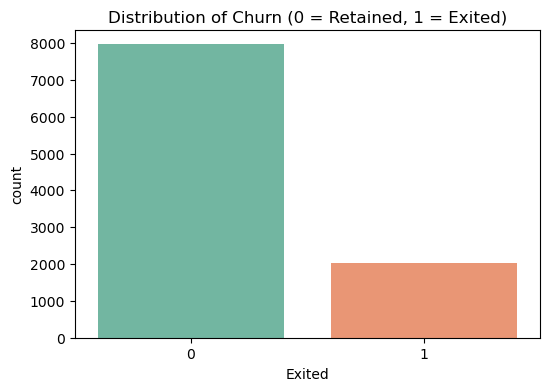

In [14]:
# 1. Visualize the Churn Rate (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Distribution of Churn (0 = Retained, 1 = Exited)')
plt.show()


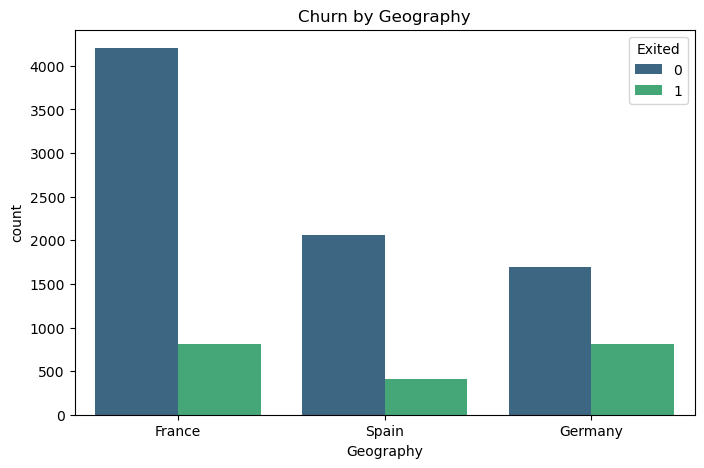

In [15]:
# 2. Visualize Churn by Geography
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=df, palette='viridis')
plt.title('Churn by Geography')
plt.show()

C:\Users\erraj\AppData\Local\Temp\ipykernel_15144\2864708239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df, palette='coolwarm')


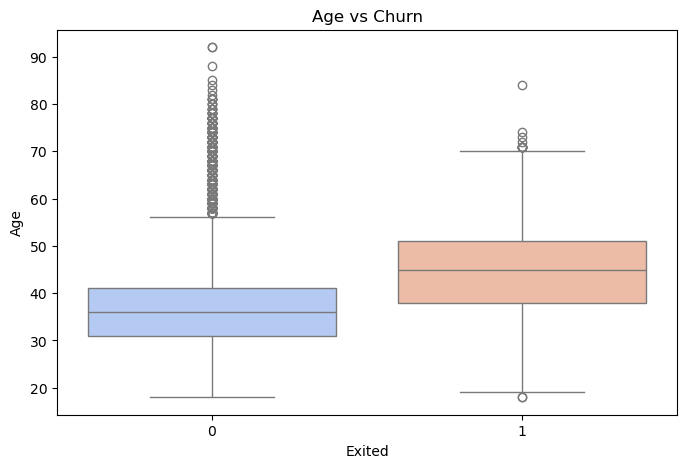

In [16]:
# 3. Visualize the impact of Age on Churn (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Exited', y='Age', data=df, palette='coolwarm')
plt.title('Age vs Churn')
plt.show()

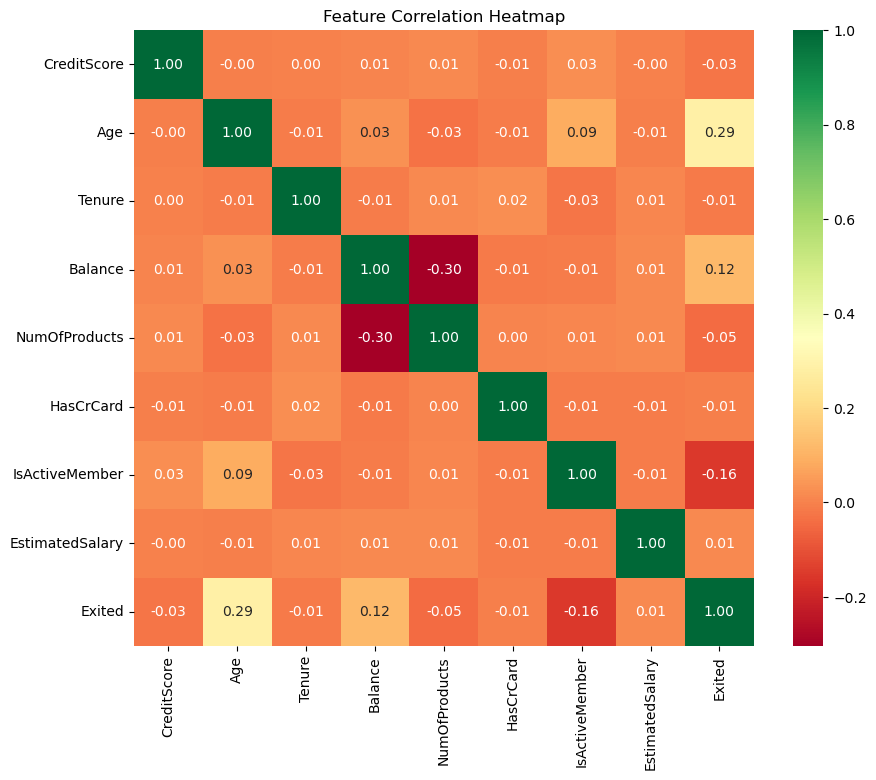

In [17]:
# 4. Correlation Heatmap (Only on numeric columns)
plt.figure(figsize=(10, 8))

# Get only the numeric columns
numeric_df = df.select_dtypes(include=[np.number]) 

# (We REMOVED the line trying to drop 'RowNumber' and 'CustomerId' here)

# Create the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Data Preprocessing

In [18]:
# 1. Convert Categorical Text to Numbers (Encoding)
# Use Pandas get_dummies for Geography (creates 1s and 0s for the countries)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Use Scikit-Learn LabelEncoder for Gender (Male = 1, Female = 0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# 2. Split data into Features (X) and Target (y)
X = df.drop('Exited', axis=1) # Everything except the target
y = df['Exited']              # Only the target (churn)

# 3. Split into Training and Testing Sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Standardizes the numbers so large values like Salary don't overpower Age)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing completed successfully! ✅")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Data Preprocessing completed successfully! ✅
Training data shape: (8000, 11)
Testing data shape: (2000, 11)


### Model Training & Evaluation

Model Accuracy: 86.65%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



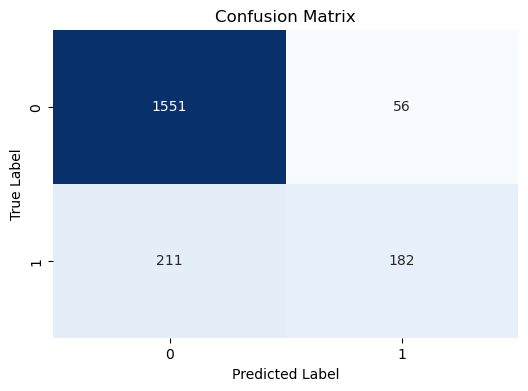

C:\Users\erraj\AppData\Local\Temp\ipykernel_15144\3877102038.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='mako')


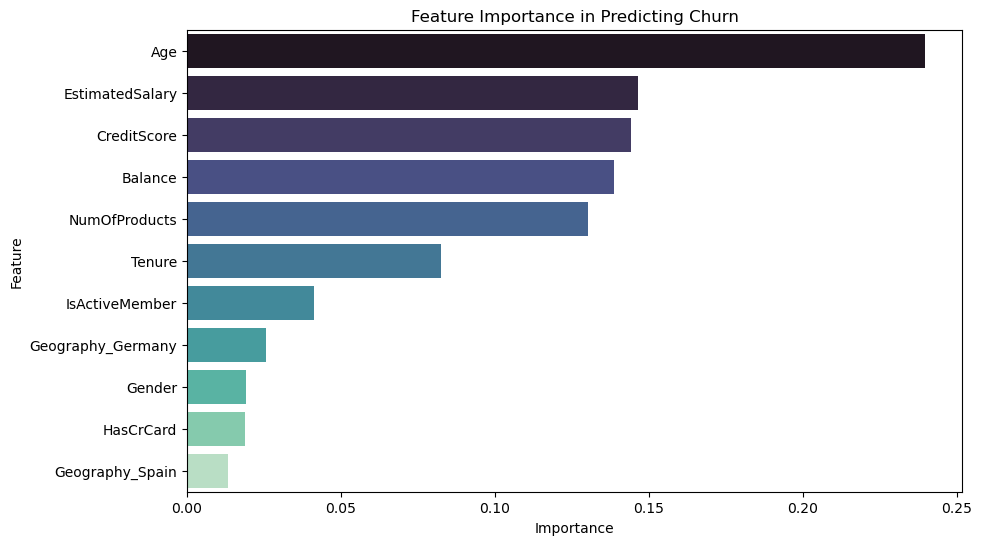

In [19]:
# 1. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Make Predictions on the test set
y_pred = model.predict(X_test_scaled)

# 3. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 5. Feature Importance (What drives churn the most?)
importances = model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='mako')
plt.title('Feature Importance in Predicting Churn')
plt.show()

In [22]:
import pickle

# Model ko save karein
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Scaler ko save karein (Kyunki naye data ko bhi scale karna padega)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved Successfully! 💾")

Model and Scaler saved Successfully! 💾
